In [ ]:
# make top level dir available
import sys
sys.path.append("../../")

import numpy as np

import fem.functions as myfunc

In [14]:
def alpha1(x, y):
    return x * y + 1

def alpha2(x, y):
    return x + y + 1

def beta(x, y):
    return 2 * np.power(x, 2)

def rhs(x, y):
    return x + np.power(y, 2)
    
# Robin Boundary Conditions
ROBIN_INDICES = np.array([
    [3, 5], [0,4], [4, 3], [5, 0]
])
def robin_gamma(x, y):
    return 2 + np.power(x, 2) + np.power(y, 2)

def robin_rhs(x, y):
    return x - y

In [15]:
DOMAIN_KNOTS = np.array([
    [1, 0.7], [0.5, 0.35], [0.5, 0.18], [0,0], [0, 0.7], [1,0]
])
ELEMENTS = np.array([
    [0, 4, 1], [3, 4, 1], [5, 0, 1], [3, 5, 2], [2, 1, 3], [5, 1, 2]
])

In [16]:
stiffness_matrix, load_vector = myfunc.assemble_global_system(DOMAIN_KNOTS, ELEMENTS, alpha1, alpha2, beta, rhs)
stiffness_matrix, load_vector = myfunc.insert_robin_values(DOMAIN_KNOTS, stiffness_matrix, load_vector, ROBIN_INDICES, robin_gamma, robin_rhs)

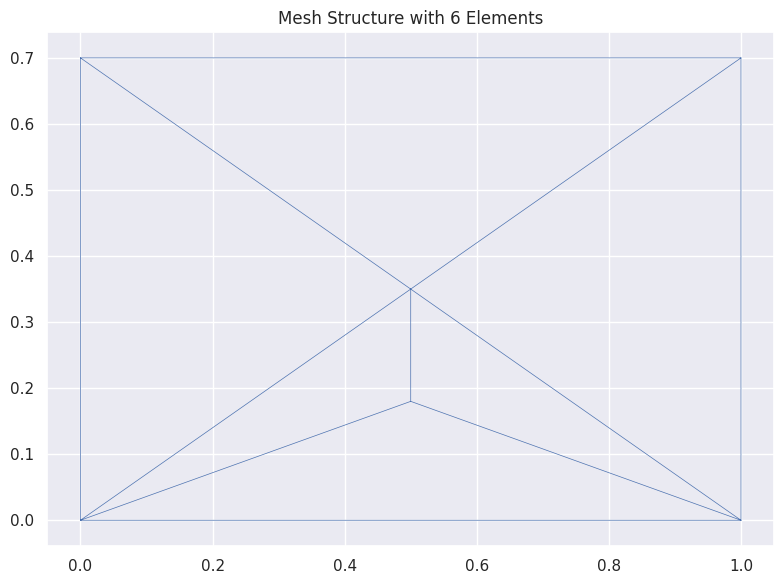

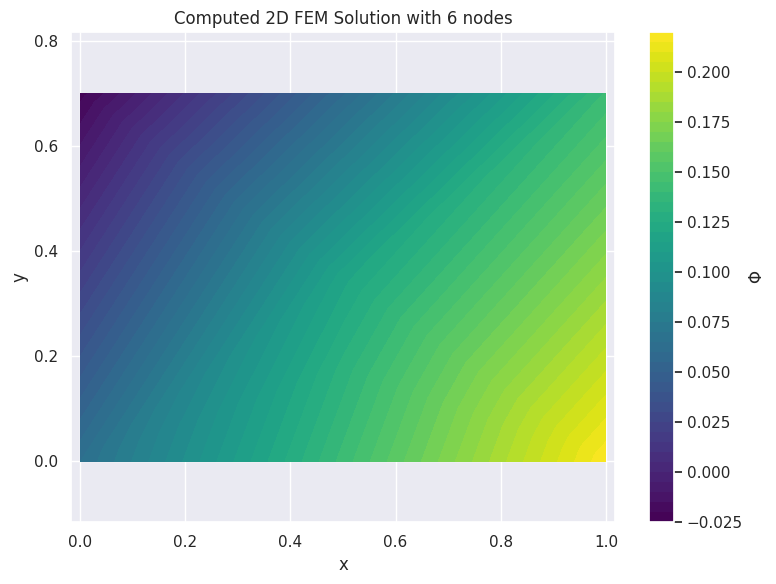

In [17]:


solution = myfunc.solve_system(DOMAIN_KNOTS, stiffness_matrix, load_vector)
myfunc.plot_result(ELEMENTS, solution, levels=50)